# Terzaghi 1D Analytical Verification Notebook

This notebook checks the analytical Fourier-series formulation for 1D single-layer consolidation in two stages:

1. recovery of the classical Terzaghi solution for a uniform initial excess pore-pressure field
2. reconstruction and term-convergence for a non-uniform Boussinesq-based initial condition using the generalised arbitrary-`u0` formulation

The main purpose is to show that the generalised analytical model behaves correctly in the uniform limit and to document how the truncated series behaves for a non-uniform initial pore-pressure profile.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical
from src.geotech_consolidation.models.terzaghi_1d.u0_analytical import Get_terzaghi1d_Analytical_u0


def boussinesq_strip_u0(z, load, base):
    z_safe = np.maximum(z, 1e-12)
    term1 = np.arctan(base / (2.0 * z_safe))
    term2 = (base * z_safe) / (2.0 * z_safe**2 + 0.5 * base**2)
    u0 = (2.0 * load / np.pi) * (term1 + term2)
    u0[np.isclose(z, 0.0)] = 0.0
    return u0


def error_metrics(reference, candidate):
    diff = reference - candidate
    rmse = np.sqrt(np.mean(diff**2))
    norm_l2 = np.sqrt(np.sum(diff**2) / (np.sum(reference**2) + 1e-12))
    return {"rmse": rmse, "norm_l2": norm_l2}


H = 5.0
num = 100
nodes = num + 1
load = 100.0
base = 3.0
Cv = 2e-7
time_steps = 1000
T = 365 * 24 * 60 * 60
time_days = np.linspace(0, T / (60 * 60 * 24), time_steps)
depth = np.linspace(0.0, H, nodes)

sns.set_theme(style="whitegrid")

## Recovery Test: Uniform Initial Condition

This section checks that the generalised arbitrary-`u0` analytical solver collapses back to the classical Terzaghi series solution when the initial excess pore pressure is uniform with depth.

Any small oscillation near the drained boundary is a Fourier-series effect caused by the incompatibility between the prescribed initial field and the zero-pressure drainage condition at the surface.

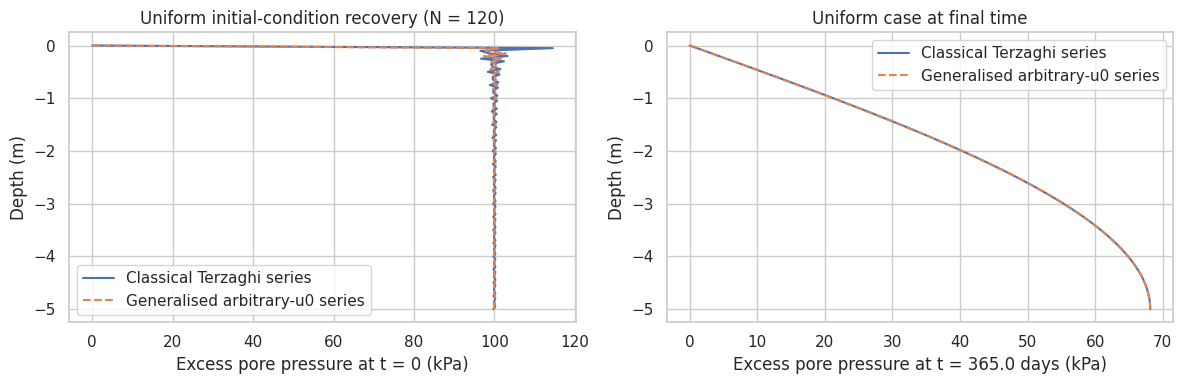

,case,rmse,norm_l2
0,t = 0,1.770977,0.017776
1,t = final,0.000993,0.000021


In [5]:
uniform_u0 = np.full(nodes, load, dtype=float)
N_terms_uniform = 120

cdata_std, u_std, depth_std, time_std = Get_terzaghi1d_Analytical(
    H, num, load, T, time_steps, Cv, N_terms_uniform
)

u_u0_uniform, _, _ = Get_terzaghi1d_Analytical_u0(
    uniform_u0, H, num, T, time_steps, Cv, N_terms_uniform
)

uniform_metrics_t0 = error_metrics(u_std[0], u_u0_uniform[0])
uniform_metrics_tend = error_metrics(u_std[-1], u_u0_uniform[-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(u_std[0], -depth_std, label="Classical Terzaghi series")
axes[0].plot(u_u0_uniform[0], -depth, "--", label="Generalised arbitrary-u0 series")
axes[0].set_xlabel("Excess pore pressure at t = 0 (kPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title(f"Uniform initial-condition recovery (N = {N_terms_uniform})")
axes[0].legend()

axes[1].plot(u_std[-1], -depth_std, label="Classical Terzaghi series")
axes[1].plot(u_u0_uniform[-1], -depth, "--", label="Generalised arbitrary-u0 series")
axes[1].set_xlabel(f"Excess pore pressure at t = {time_std[-1]:.1f} days (kPa)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Uniform case at final time")
axes[1].legend()

plt.tight_layout()
plt.show()

pd.DataFrame(
    [
        {"case": "t = 0", **uniform_metrics_t0},
        {"case": "t = final", **uniform_metrics_tend},
    ]
)

## Boussinesq Initial Condition: Reconstruction and `N`-Convergence

Here the prescribed initial excess pore-pressure field is derived from a Boussinesq-based strip-load profile. The arbitrary-`u0` Fourier solver is then used to:

1. reconstruct the initial field at `t = 0`
2. assess how the truncated Fourier series converges as the number of retained terms increases

The reference for the reconstruction error is the prescribed `u0(z)` itself.

,rmse,norm_l2
n_terms,,
20,7.573232e+00,1.098280e-01
40,3.697400e+00,5.362017e-02
60,1.759117e+00,2.551094e-02
80,5.819926e-01,8.440132e-03
100,5.270503e-13,7.643351e-15
120,5.819926e-01,8.440132e-03
160,3.697400e+00,5.362017e-02
180,7.573232e+00,1.098280e-01
200,6.895539e+01,1.000000e+00


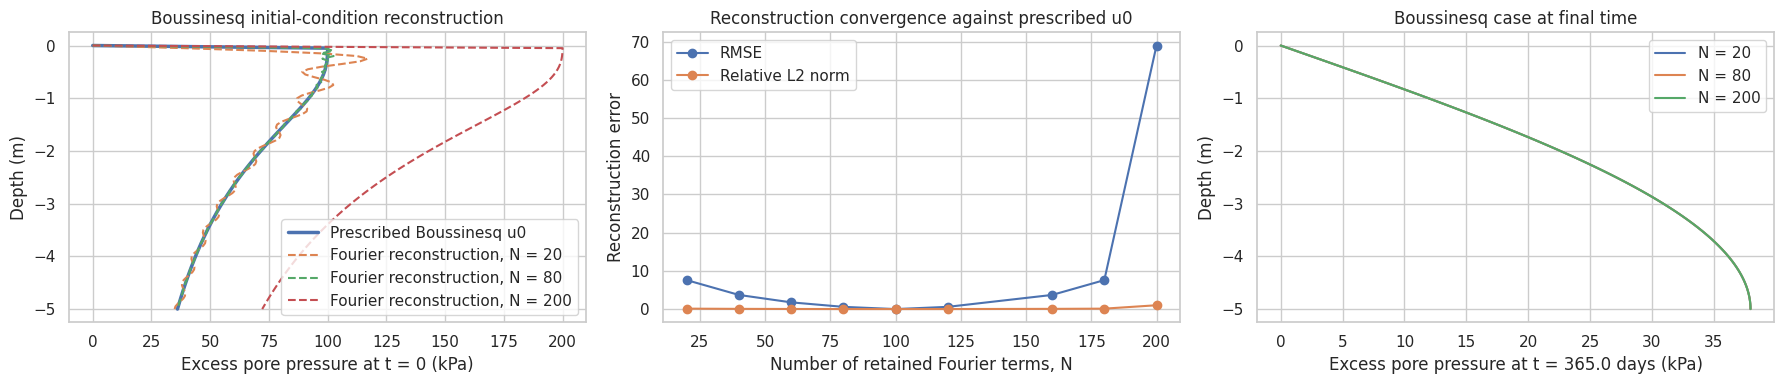

In [3]:
boussinesq_u0 = boussinesq_strip_u0(depth, load, base)
n_values = [20, 40, 60, 80, 100, 120, 160, 180, 200]
solutions = {}
results = []

for n in n_values:
    u_data, _, _ = Get_terzaghi1d_Analytical_u0(
        boussinesq_u0, H, num, T, time_steps, Cv, n
    )
    solutions[n] = u_data
    metrics = error_metrics(boussinesq_u0, u_data[0])
    metrics["n_terms"] = n
    results.append(metrics)

df_conv = pd.DataFrame(results).set_index("n_terms")
display(df_conv)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(boussinesq_u0, -depth, linewidth=2.5, label="Prescribed Boussinesq u0")
for n in [20, 80, 200]:
    axes[0].plot(solutions[n][0], -depth, "--", label=f"Fourier reconstruction, N = {n}")
axes[0].set_xlabel("Excess pore pressure at t = 0 (kPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Boussinesq initial-condition reconstruction")
axes[0].legend()

axes[1].plot(df_conv.index, df_conv["rmse"], marker="o", label="RMSE")
axes[1].plot(df_conv.index, df_conv["norm_l2"], marker="o", label="Relative L2 norm")
axes[1].set_xlabel("Number of retained Fourier terms, N")
axes[1].set_ylabel("Reconstruction error")
axes[1].set_title("Reconstruction convergence against prescribed u0")
axes[1].legend()

for n in [20, 80, 200]:
    axes[2].plot(solutions[n][-1], -depth, label=f"N = {n}")
axes[2].set_xlabel(f"Excess pore pressure at t = {time_days[-1]:.1f} days (kPa)")
axes[2].set_ylabel("Depth (m)")
axes[2].set_title("Boussinesq case at final time")
axes[2].legend()

plt.tight_layout()
plt.show()

## Short Note on Total Settlement and Quadrature

For 1D consolidation, a common post-processing step is to estimate the settlement from the strain field

`epsilon_v(z, t) = Mv [u0(z) - u(z, t)]`

and then integrate through the layer depth:

`s(t) = integral_0^H epsilon_v(z, t) dz`

Numerically, that depth integral must be approximated by a quadrature rule. Two practical options are:

- rectangle-rule style summation: `sum(epsilon_v * dz)`
- trapezoidal integration: `trapz(epsilon_v, z)`

In the analytical arbitrary-`u0` formulation, the Fourier coefficients are already obtained using trapezoidal integration in [u0_analytical.py](/Users/uthmanaziz/Desktop/Github/Consolidation-FEM/Geotechnical-Consolidation-FEM-1/src/geotech_consolidation/models/terzaghi_1d/u0_analytical.py). For FEM settlement post-processing, it is worth stating explicitly which quadrature choice is used, because a change in the depth integration rule can alter the reported total settlement even when the pore-pressure field itself is unchanged.